<a href="https://colab.research.google.com/github/keerthanaponugumati/research-projects/blob/main/neuroq_intent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q mne scikit-learn matplotlib numpy pandas qiskit qiskit-machine-learning qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from mne.datasets import eegbci
from mne.io import read_raw_edf, concatenate_raws
from mne.channels import make_standard_montage
from mne.decoding import CSP

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
subject = 1
runs = [6, 10, 14]

print("Subject:", subject)
print("Runs:", runs)

Subject: 1
Runs: [6, 10, 14]


In [ ]:
raw_fnames = eegbci.load_data(subject, runs)

raw_files = []

for fname in raw_fnames:
    raw_file = read_raw_edf(fname, preload=True)
    raw_files.append(raw_file)

raw = concatenate_raws(raw_files)

print(raw)

Using default location ~/mne_data for EEGBCI...
Creating /root/mne_data


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 06m15s (7.4 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R14.edf...
Setting channel info structure...
Creating raw.info structure...
Re

In [ ]:
eegbci.standardize(raw)

montage = make_standard_montage("standard_1005")

raw.set_montage(montage)

print("Montage applied.")

Montage applied.


In [ ]:
print(raw.annotations)

raw.annotations.rename({
    "T1": "hands",
    "T2": "feet"
})

print(raw.annotations)

<Annotations | 94 segments: BAD boundary (2), EDGE boundary (2), T0 (45), ...>
<Annotations | 94 segments: BAD boundary (2), EDGE boundary (2), T0 (45), ...>


In [ ]:
raw.set_eeg_reference(projection=True)

raw.filter(7.0, 30.0, fir_design="firwin", skip_by_annotation="edge")

print("Reference and filter applied.")

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Reference and filter applied.


In [ ]:
events, event_id_all = mne.events_from_annotations(raw)

print("All event IDs:")
print(event_id_all)

event_id = {
    "hands": event_id_all["hands"],
    "feet": event_id_all["feet"]
}

print("Selected event IDs:")
print(event_id)

Used Annotations descriptions: [np.str_('T0'), np.str_('feet'), np.str_('hands')]
All event IDs:
{np.str_('T0'): 1, np.str_('feet'): 2, np.str_('hands'): 3}
Selected event IDs:
{'hands': 3, 'feet': 2}


In [ ]:
picks = mne.pick_types(
    raw.info,
    meg=False,
    eeg=True,
    stim=False,
    eog=False,
    exclude="bads"
)

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=-1.0,
    tmax=4.0,
    proj=True,
    picks=picks,
    baseline=None,
    preload=True
)

print(epochs)

Not setting metadata
45 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 45 events and 801 original time points ...
0 bad epochs dropped
<Epochs | 45 events (all good), -1 – 4 s (baseline off), ~17.7 MiB, data loaded,
 'hands': 21
 'feet': 24>


In [ ]:
epochs_train = epochs.copy().crop(tmin=1.0, tmax=2.0)

X = epochs_train.get_data()

labels = epochs_train.events[:, -1]

y = (labels == event_id["feet"]).astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))
print("Meaning: 0 = hands, 1 = feet")

X shape: (45, 64, 161)
y shape: (45,)
Unique labels: [0 1]
Meaning: 0 = hands, 1 = feet


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

csp_lda = Pipeline([
    ("CSP", CSP(n_components=4, reg=None, log=True, norm_trace=False)),
    ("LDA", LinearDiscriminantAnalysis())
])

scores = cross_val_score(
    csp_lda,
    X,
    y,
    cv=cv
)

print("CSP + LDA cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Computing rank from data with rank=None
    Using tolerance 7.3e-05 (2.2e-16 eps * 64 dim * 5.1e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 7e-05 (2.2e-16 eps * 64 dim * 4.9e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 7e-0

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

csp_lda.fit(X_train, y_train)

y_pred_classical = csp_lda.predict(X_test)

acc_classical = accuracy_score(y_test, y_pred_classical)

print("Classical CSP + LDA accuracy:", acc_classical)
print(classification_report(y_test, y_pred_classical, target_names=["hands", "feet"]))

Computing rank from data with rank=None
    Using tolerance 6.8e-05 (2.2e-16 eps * 64 dim * 4.8e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Classical CSP + LDA accuracy: 1.0
              precision    recall  f1-score   support

       hands       1.00      1.00      1.00         6
        feet       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



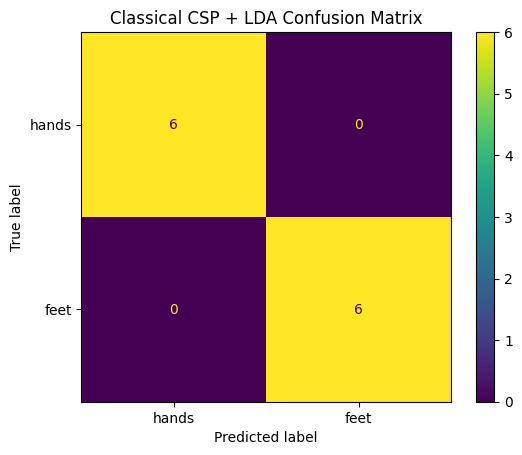

In [ ]:
cm_classical = confusion_matrix(y_test, y_pred_classical)

disp_classical = ConfusionMatrixDisplay(
    confusion_matrix=cm_classical,
    display_labels=["hands", "feet"]
)

disp_classical.plot()

plt.title("Classical CSP + LDA Confusion Matrix")

plt.savefig("classical_confusion_matrix.png", dpi=200, bbox_inches="tight")

plt.show()

In [ ]:
csp_for_features = CSP(
    n_components=2,
    reg=None,
    log=True,
    norm_trace=False
)

X_train_csp = csp_for_features.fit_transform(X_train, y_train)

X_test_csp = csp_for_features.transform(X_test)

print("Training CSP feature shape:", X_train_csp.shape)
print("Testing CSP feature shape:", X_test_csp.shape)

Computing rank from data with rank=None
    Using tolerance 6.8e-05 (2.2e-16 eps * 64 dim * 4.8e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Training CSP feature shape: (33, 2)
Testing CSP feature shape: (12, 2)


In [ ]:
classical_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

classical_svm.fit(X_train_csp, y_train)

y_pred_svm = classical_svm.predict(X_test_csp)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("Classical RBF SVM accuracy:", acc_svm)
print(classification_report(y_test, y_pred_svm, target_names=["hands", "feet"]))

Classical RBF SVM accuracy: 0.9166666666666666
              precision    recall  f1-score   support

       hands       0.86      1.00      0.92         6
        feet       1.00      0.83      0.91         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12



In [ ]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

try:
    from qiskit.circuit.library import zz_feature_map
except ImportError:
    from qiskit.circuit.library import ZZFeatureMap

    def zz_feature_map(feature_dimension, reps=2, entanglement="linear"):
        return ZZFeatureMap(
            feature_dimension=feature_dimension,
            reps=reps,
            entanglement=entanglement
        )

In [ ]:
quantum_scaler = MinMaxScaler(feature_range=(0, np.pi))

X_train_q = quantum_scaler.fit_transform(X_train_csp)

X_test_q = quantum_scaler.transform(X_test_csp)

print("Quantum training feature range:")
print(X_train_q.min(), X_train_q.max())

print("Quantum testing feature shape:", X_test_q.shape)

Quantum training feature range:
0.0 3.1415926535897936
Quantum testing feature shape: (12, 2)


In [ ]:
num_features = X_train_q.shape[1]

feature_map = zz_feature_map(
    feature_dimension=num_features,
    reps=2,
    entanglement="linear"
)

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

qsvc = QSVC(
    quantum_kernel=quantum_kernel
)

qsvc.fit(X_train_q, y_train)

y_pred_quantum = qsvc.predict(X_test_q)

acc_quantum = accuracy_score(y_test, y_pred_quantum)

print("Quantum Kernel SVM accuracy:", acc_quantum)
print(classification_report(y_test, y_pred_quantum, target_names=["hands", "feet"]))

Quantum Kernel SVM accuracy: 1.0
              precision    recall  f1-score   support

       hands       1.00      1.00      1.00         6
        feet       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



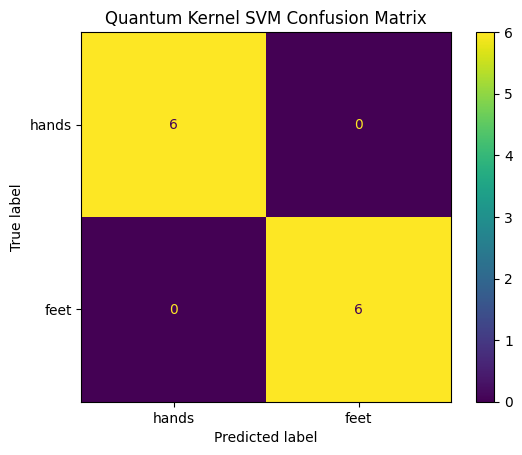

In [ ]:
cm_quantum = confusion_matrix(y_test, y_pred_quantum)

disp_quantum = ConfusionMatrixDisplay(
    confusion_matrix=cm_quantum,
    display_labels=["hands", "feet"]
)

disp_quantum.plot()

plt.title("Quantum Kernel SVM Confusion Matrix")

plt.savefig("quantum_confusion_matrix.png", dpi=200, bbox_inches="tight")

plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": [
        "CSP + LDA",
        "CSP features + Classical RBF SVM",
        "CSP features + Quantum Kernel SVM"
    ],
    "Accuracy": [
        acc_classical,
        acc_svm,
        acc_quantum
    ],
    "Feature Setup": [
        "CSP inside pipeline",
        "2 CSP features",
        "2 CSP features scaled to 0-pi"
    ]
})

results

,Model,Accuracy,Feature Setup
0,CSP + LDA,1.000000,CSP inside pipeline
1,CSP features + Classical RBF SVM,0.916667,2 CSP features
2,CSP features + Quantum Kernel SVM,1.000000,2 CSP features scaled to 0-pi


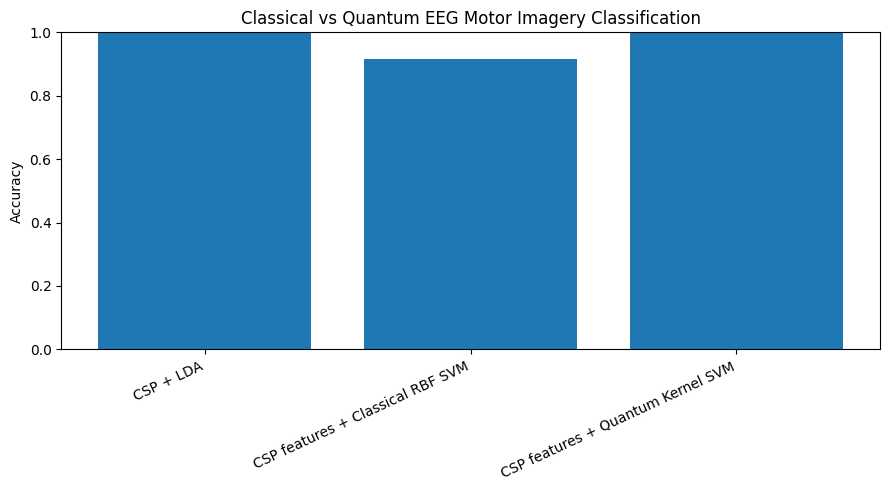

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(results["Model"], results["Accuracy"])

plt.ylim(0, 1)

plt.ylabel("Accuracy")

plt.title("Classical vs Quantum EEG Motor Imagery Classification")

plt.xticks(rotation=25, ha="right")

plt.tight_layout()

plt.savefig("model_comparison.png", dpi=200, bbox_inches="tight")

plt.show()

In [ ]:
results.to_csv("model_comparison.csv", index=False)

print("Saved model_comparison.csv")

Saved model_comparison.csv


In [ ]:
readme_text = f"""
# NeuroQ-Intent

## Project Goal

This project explores the intersection of neurotechnology and quantum machine learning.

The goal is to classify EEG motor imagery signals into two classes:

- hands imagery
- feet imagery

## Dataset

Dataset: EEGBCI via MNE-Python
Subject: {subject}
Runs: {runs}

## Method

The pipeline used in this project was:

Raw EEG
→ channel standardization
→ electrode montage
→ 7-30 Hz filtering
→ epoch creation
→ CSP feature extraction
→ classical and quantum-kernel classification

## Models Compared

1. CSP + LDA
2. CSP features + Classical RBF SVM
3. CSP features + Quantum Kernel SVM

## Results

{results.to_markdown(index=False)}

## Interpretation

The CSP + LDA model is the classical neurotech baseline.

The classical RBF SVM tests a nonlinear classical model on compact CSP features.

The quantum kernel SVM maps the same CSP features into a quantum feature space and uses a quantum kernel for classification.

This project does not prove quantum advantage. It demonstrates a realistic same-day prototype connecting EEG-based neurotechnology with quantum machine learning.

## Limitations

This is not a medical device.

This project uses one subject and a small number of trials.

The quantum model is exploratory.

The results may change with more subjects, different preprocessing choices, and different quantum feature maps.

## Future Work

- Test more subjects.
- Try left-hand vs right-hand motor imagery.
- Compare different CSP component counts.
- Try other quantum feature maps.
- Test cross-subject generalization.
"""

with open("README.md", "w") as f:
    f.write(readme_text)

print(readme_text)


# NeuroQ-Intent

## Project Goal

This project explores the intersection of neurotechnology and quantum machine learning.

The goal is to classify EEG motor imagery signals into two classes:

- hands imagery
- feet imagery

## Dataset

Dataset: EEGBCI via MNE-Python  
Subject: 1  
Runs: [6, 10, 14]  

## Method

The pipeline used in this project was:

Raw EEG  
→ channel standardization  
→ electrode montage  
→ 7-30 Hz filtering  
→ epoch creation  
→ CSP feature extraction  
→ classical and quantum-kernel classification  

## Models Compared

1. CSP + LDA
2. CSP features + Classical RBF SVM
3. CSP features + Quantum Kernel SVM

## Results

| Model                             |   Accuracy | Feature Setup                 |
|:----------------------------------|-----------:|:------------------------------|
| CSP + LDA                         |   1        | CSP inside pipeline           |
| CSP features + Classical RBF SVM  |   0.916667 | 2 CSP features                |
| CSP features + 